In [3]:
import pandas as pd

In [4]:
guidelines_df_list = list()
TOTAL_NUM_GUIDELINES = 10

for i in range(1, TOTAL_NUM_GUIDELINES + 1):
    guidelines_df_list.append(
        pd.read_excel(f"guidelines_analysis.xlsx", sheet_name=str(i))
    )

guidelines_df = pd.concat(guidelines_df_list, ignore_index=True)


In [5]:
df_guidelines_name = pd.read_excel(f"guidelines_analysis.xlsx", sheet_name="Guidelines")

guideline_1 = df_guidelines_name.iloc[1:, 0:2].dropna(),
guideline_2 = df_guidelines_name.iloc[1:, 2:4].dropna(),
guideline_3 = df_guidelines_name.iloc[1:, 4:6].dropna(),
guideline_4 = df_guidelines_name.iloc[1:, 6:8].dropna(),

list_of_guidelines_names = [
    df_guidelines_name.iloc[1:, 0:2].dropna().iloc[:,0],
]
df_guidelines_name = pd.DataFrame({
    "Code": pd.concat([guideline_1[0].iloc[:, 0], guideline_2[0].iloc[:, 0], guideline_3[0].iloc[:, 0], guideline_4[0].iloc[:, 0]], ignore_index=True),
    "Description": pd.concat([guideline_1[0].iloc[:, 1], guideline_2[0].iloc[:, 1], guideline_3[0].iloc[:, 1], guideline_4[0].iloc[:, 1]], ignore_index=True)
})

In [6]:
print(f"Total number of guidelines: {len(guidelines_df)}")
guidelines_df.head()

Total number of guidelines: 514


,Código,Nombre de la pauta,Fragmento del documento que incumple
0,6.1.1,Evitar mayúsculas,MODELO DE CONSENTIMIENTO EXPRESO
1,6.1.1,Evitar mayúsculas,ANEXO I. INFORMACIÓN ADICIONAL SOBRE PROTECCIÓ...
2,6.1.8,Evitar paréntesis y signos poco habituales,(Servicio de Innovación Educativa)
3,6.1.8,Evitar paréntesis y signos poco habituales,utilización y/o difusión (uso de la barra)
4,6.1.8,Evitar paréntesis y signos poco habituales,Reglamento (UE) 2016/679


In [7]:
guidelines_to_analyze = guidelines_df["Código"].sort_values().unique()
guidelines_codes_in_e2r_std = df_guidelines_name["Code"].sort_values().unique()

In [8]:
guidelines_to_analyze

<ArrowStringArray>
[ '6.1.1', '6.1.10',  '6.1.3',  '6.1.7',  '6.1.8',  '6.1.9',  '6.2.1',
 '6.2.10', '6.2.11', '6.2.12', '6.2.18', '6.2.19', '6.2.20', '6.2.22',
 '6.2.23', '6.2.25',  '6.2.4',  '6.2.7',  '6.2.9',  '6.3.1', '6.3.10',
 '6.3.11', '6.3.13', '6.3.14', '6.3.15', '6.3.16',  '6.3.3',  '6.3.4',
  '6.3.5',  '6.3.7',  '6.3.8',  '6.3.9',  '6.4.4',  '6.4.6',  '6.4.8',
  '6.4.9']
Length: 36, dtype: str

In [9]:
guidelines_codes_in_e2r_std

<ArrowStringArray>
[ '6.1.1', '6.1.10',  '6.1.2',  '6.1.3',  '6.1.4',  '6.1.5',  '6.1.6',
  '6.1.7',  '6.1.8',  '6.1.9',  '6.2.1', '6.2.10', '6.2.11', '6.2.12',
 '6.2.13', '6.2.14', '6.2.15', '6.2.16', '6.2.17', '6.2.18', '6.2.19',
  '6.2.2', '6.2.20', '6.2.21', '6.2.22', '6.2.23', '6.2.24', '6.2.25',
  '6.2.3',  '6.2.4',  '6.2.5',  '6.2.6',  '6.2.7',  '6.2.8',  '6.2.9',
  '6.3.1', '6.3.10', '6.3.11', '6.3.12', '6.3.13', '6.3.14', '6.3.15',
 '6.3.16',  '6.3.2',  '6.3.3',  '6.3.4',  '6.3.5',  '6.3.6',  '6.3.7',
  '6.3.8',  '6.3.9',  '6.4.1',  '6.4.2',  '6.4.3',  '6.4.4',  '6.4.5',
  '6.4.6',  '6.4.7',  '6.4.8',  '6.4.9']
Length: 60, dtype: str

In [10]:
if not set(guidelines_to_analyze).difference(set(guidelines_codes_in_e2r_std)):
    print("All guidelines to analyze are present in the E2R standard.")

All guidelines to analyze are present in the E2R standard.


In [11]:
freq_df = (
    guidelines_df.groupby(["Código"])
    .size()
    .reset_index(name="Frecuencia")
    .merge(df_guidelines_name, left_on="Código", right_on="Code", how="left")
    .drop(columns="Code")
    .sort_values("Frecuencia", ascending=False)
    .reset_index(drop=True)
)
freq_df

,Código,Frecuencia,Description
0,6.1.8,57,"Evitar paréntesis, corchetes y signos poco hab..."
1,6.2.4,48,"Evitar términos abstractos, técnicos o complejos."
2,6.1.1,41,"No escribir palabras ni frases en mayúsculas, ..."
3,6.2.7,36,Evitar adverbios terminados en -mente.
4,6.3.5,31,Evitar la pasiva refleja.
5,6.3.4,30,Evitar la voz pasiva.
6,6.2.11,29,Evitar abreviaturas.
7,6.3.3,27,"Evitar tiempos compuestos, condicionales y sub..."
8,6.3.13,23,Evitar incisos entre comas.
9,6.2.12,20,Evitar el uso de siglas.


In [12]:
most_frequent = freq_df.iloc[0]
print(f"Pauta con más incumplimientos: {most_frequent['Código']} — {most_frequent['Description']}")
print(f"Frecuencia: {most_frequent['Frecuencia']}")

Pauta con más incumplimientos: 6.1.8 — Evitar paréntesis, corchetes y signos poco habituales (%, &, /, etc.).
Frecuencia: 57


In [13]:
least_frequent = freq_df.iloc[-1]
print(f"Pauta con menos incumplimientos: {least_frequent['Código']} — {least_frequent['Description']}")
print(f"Frecuencia: {least_frequent['Frecuencia']}")

Pauta con menos incumplimientos: 6.3.14 — Evitar aposiciones que corten el ritmo de la lectura.
Frecuencia: 1


In [14]:
fragments_by_guideline = (
    guidelines_df.groupby(["Código"])["Fragmento del documento que incumple"]
    .apply(list)
    .reset_index()
    .merge(df_guidelines_name, left_on="Código", right_on="Code", how="left")
    .drop(columns="Code")
    .rename(columns={"Fragmento del documento que incumple": "Fragmentos", "Description": "Descripción E2R"})
    .sort_values("Código")
    .reset_index(drop=True)
)
fragments_by_guideline

,Código,Fragmentos,Descripción E2R
0,6.1.1,"[MODELO DE CONSENTIMIENTO EXPRESO, ANEXO I. IN...","No escribir palabras ni frases en mayúsculas, ..."
1,6.1.10,[“Se ha establecido un sistema de anonimizació...,"No usar comillas; si se usan, deben acompañars..."
2,6.1.3,[Por la firma de la presente cláusula D./D.ª _...,Usar punto y aparte para separar ideas diferen...
3,6.1.7,[Indíquense especialmente los riesgos para la ...,No utilizar el punto y coma (;).
4,6.1.8,"[(Servicio de Innovación Educativa), utilizaci...","Evitar paréntesis, corchetes y signos poco hab..."
5,6.1.9,"[fines educativos, informativos, de promoción ...",No utilizar etcétera ni puntos suspensivos (…).
6,6.2.1,[La presente autorización se realiza de forma ...,Lenguaje sencillo y de uso frecuente.
7,6.2.10,"[3.0 España License de Creative Commons, prest...",Evitar palabras de otros idiomas si no son de ...
8,6.2.11,"[C. Ramiro de Maeztu nº 7. 28040 Madrid, Tlf: ...",Evitar abreviaturas.
9,6.2.12,[UPM (utilizado a lo largo del documento sin e...,Evitar el uso de siglas.


In [15]:
fragments_by_guideline.to_excel("fragments_by_guideline.xlsx", index=False)

## Table 5.1 — Top-10 Violated E2R Guidelines (Paper Export)

In [16]:
# English descriptions for the 36 violated guidelines (used in Table 5.1)
EN_DESCRIPTIONS = {
    '6.1.1':  'Avoid uppercase letters or words',
    '6.1.3':  'Use paragraph breaks to separate ideas',
    '6.1.7':  'Do not use semicolons',
    '6.1.8':  'Avoid parentheses, brackets, and unusual symbols (%, &, /)',
    '6.1.9':  'Do not use "etcetera" or ellipses',
    '6.1.10': 'Do not use quotation marks (unless accompanied by explanation)',
    '6.2.1':  'Use simple, frequently-used language',
    '6.2.4':  'Avoid abstract, technical, or complex terms',
    '6.2.7':  'Avoid adverbs ending in -mente',
    '6.2.9':  'Avoid words that add no information',
    '6.2.10': 'Avoid foreign-language words if not widely used',
    '6.2.11': 'Avoid abbreviations',
    '6.2.12': 'Avoid acronyms',
    '6.2.18': 'Avoid vague words (cosa, algo, aspecto)',
    '6.2.19': 'Write numbers as digits; explain complex numbers',
    '6.2.20': 'Separate phone numbers into blocks',
    '6.2.22': 'Avoid fractions and percentages; describe them in words',
    '6.2.23': 'Avoid date formats with dashes or slashes',
    '6.2.25': 'Avoid Roman numerals (except centuries, kings, popes)',
    '6.3.1':  'Simple sentences; avoid complex clauses',
    '6.3.3':  'Avoid compound tenses, conditionals, and subjunctives',
    '6.3.4':  'Avoid passive voice',
    '6.3.5':  'Avoid reflexive passive voice',
    '6.3.7':  'Avoid impersonal sentences',
    '6.3.8':  'Avoid gerund constructions',
    '6.3.9':  'Avoid two or more successive verbs (except periphrases)',
    '6.3.10': 'Prefer affirmative sentences',
    '6.3.11': 'Negation must be clear; avoid double negatives',
    '6.3.13': 'Avoid incidental clauses enclosed by commas',
    '6.3.14': 'Avoid appositions that disrupt reading flow',
    '6.3.15': 'Do not present more than two ideas in one sentence',
    '6.3.16': 'Avoid complex connectors (therefore, nevertheless, etc.)',
    '6.4.4':  'Use titles that anticipate content',
    '6.4.6':  'Use lists when there are multiple elements',
    '6.4.8':  'Address the reader directly when appropriate',
    '6.4.9':  'Use non-sexist language with generic terms',
}

# Build paper-ready Table 5.1 (all 36 violated guidelines ranked by frequency)
table_5_1 = freq_df.copy()
table_5_1['Guideline (EN)'] = table_5_1['Código'].map(EN_DESCRIPTIONS)
table_5_1 = table_5_1[['Código', 'Guideline (EN)', 'Frecuencia']].rename(columns={
    'Código': 'Code', 'Frecuencia': 'Violations'
})
table_5_1 = table_5_1.sort_values('Violations', ascending=False).reset_index(drop=True)

print(f"Total violations: {table_5_1['Violations'].sum()}")
print(f"Unique guidelines violated: {len(table_5_1)}")
display(table_5_1)

# Export for paper
table_5_1.to_excel('table_5_1_guideline_violations.xlsx', index=False)
print("Saved: table_5_1_guideline_violations.xlsx")


Total violations: 514
Unique guidelines violated: 36


,Code,Guideline (EN),Violations
0,6.1.8,"Avoid parentheses, brackets, and unusual symbo...",57
1,6.2.4,"Avoid abstract, technical, or complex terms",48
2,6.1.1,Avoid uppercase letters or words,41
3,6.2.7,Avoid adverbs ending in -mente,36
4,6.3.5,Avoid reflexive passive voice,31
5,6.3.4,Avoid passive voice,30
6,6.2.11,Avoid abbreviations,29
7,6.3.3,"Avoid compound tenses, conditionals, and subju...",27
8,6.3.13,Avoid incidental clauses enclosed by commas,23
9,6.2.12,Avoid acronyms,20


Saved: table_5_1_guideline_violations.xlsx


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\prestamo_admin\AppData\Local\Temp\ipykernel_22084\1995263856.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


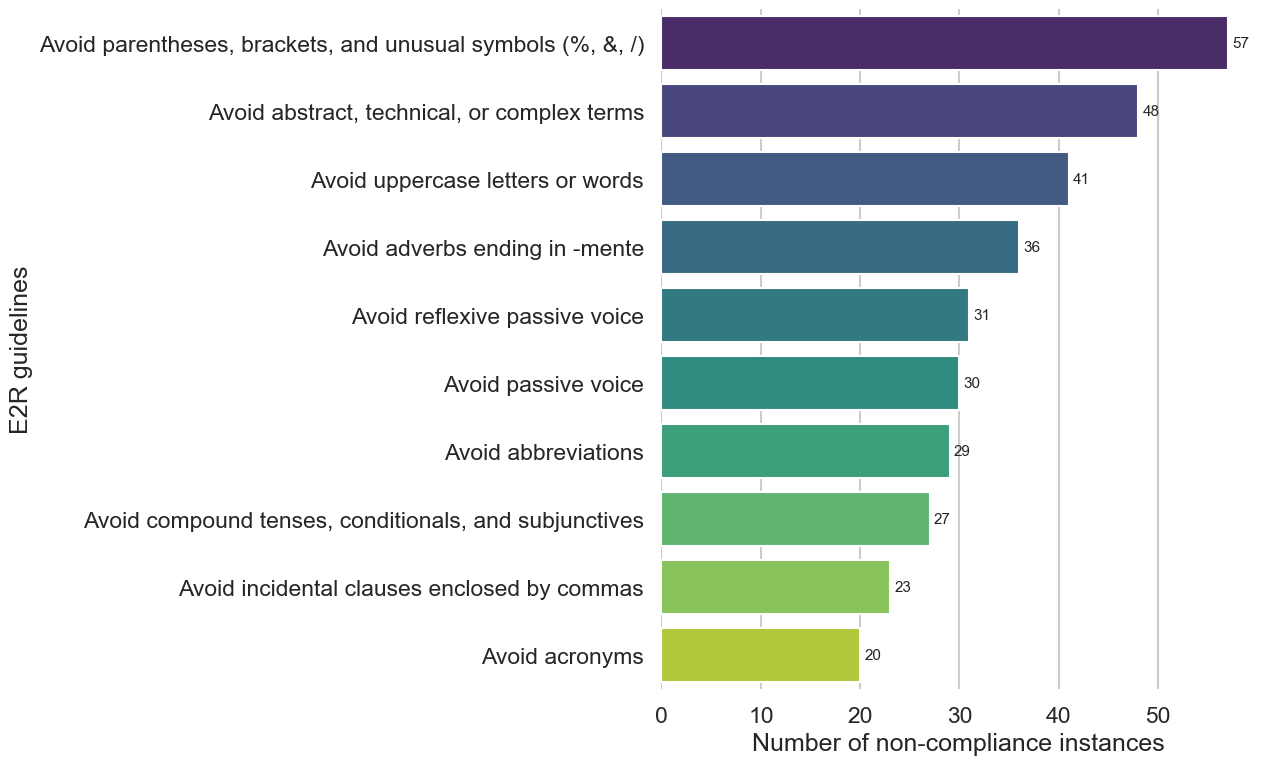

<Figure size 640x480 with 0 Axes>

In [18]:
# Estilo más limpio
sns.set_theme(style="whitegrid", context="talk")

# Tomar el top 10 y ordenar para que el mayor quede arriba
plot_df = table_5_1.sort_values("Violations", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(13, 8))

bars = sns.barplot(
    data=plot_df,
    x="Violations",
    y="Guideline (EN)",
    palette="viridis",
    ax=ax
)

# Títulos y etiquetas más claros
# ax.set_title("Top 10 E2R Guidelines with Highest Non-Compliance", pad=15, fontweight="bold")
ax.set_xlabel("Number of non-compliance instances")
ax.set_ylabel("E2R guidelines")

# Quitar bordes innecesarios
sns.despine(left=True, bottom=True)

# Etiquetas con el valor al final de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", label_type="edge", padding=3, fontsize=11)

plt.tight_layout()
plt.show()

# Guardar en PNG
fig.savefig("top_10_guidelines.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

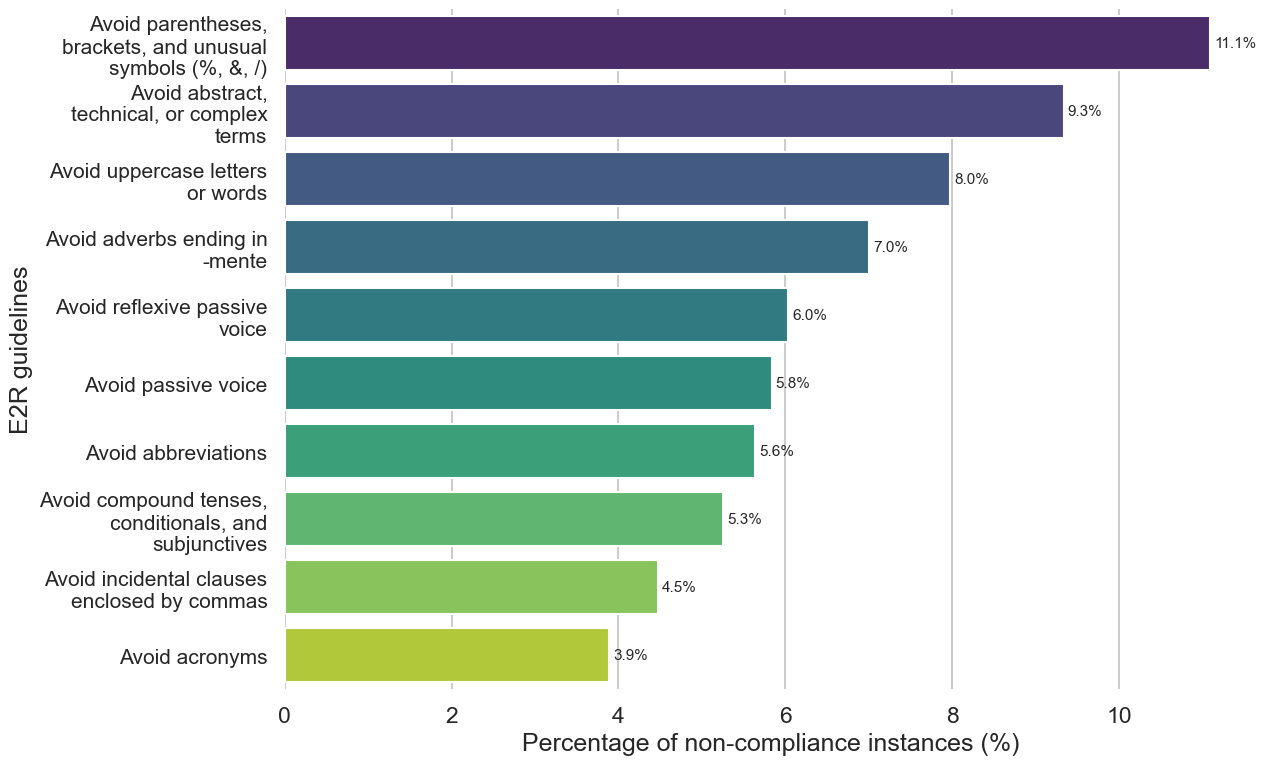

<Figure size 640x480 with 0 Axes>

In [21]:
# Versión en porcentajes
from textwrap import fill

sns.set_theme(style="whitegrid", context="talk")

# Tomar el top 10 y convertirlo a porcentaje sobre el total de incumplimientos
plot_df = table_5_1.sort_values("Violations", ascending=False).head(10).copy()
total_violations = table_5_1["Violations"].sum()
plot_df["Percentage"] = (plot_df["Violations"] / total_violations) * 100

fig, ax = plt.subplots(figsize=(13, 8))

bars = sns.barplot(
    data=plot_df,
    x="Percentage",
    y="Guideline (EN)",
    hue="Guideline (EN)",
    dodge=False,
    palette="viridis",
    legend=False,
    ax=ax
)

# Hacer más legibles los nombres del eje Y
wrapped_labels = [fill(label, width=24) for label in plot_df["Guideline (EN)"]]
ax.set_yticks(ax.get_yticks(), wrapped_labels, fontsize=15)

# Títulos y etiquetas más claros
# ax.set_title("Top 10 E2R Guidelines with Highest Non-Compliance", pad=15, fontweight="bold")
ax.set_xlabel("Percentage of non-compliance instances (%)")
ax.set_ylabel("E2R guidelines")

# Quitar bordes innecesarios
sns.despine(left=True, bottom=True)

# Etiquetas con el porcentaje al final de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="edge", padding=3, fontsize=11)

plt.tight_layout()
plt.show()

# Guardar en PNG
fig.savefig("top_10_guidelines_percentage.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()